In [11]:
import cityseg
from pathlib import Path

EXAMPLE_DIR = Path().parent / "example_inputs"
# Set the path to the example image
# This image should be a screenshot of a city map or similar
test_image = EXAMPLE_DIR / "EustonTap-Screenshot1.png"

# Load the image using cityseg
# This will return a Dataset object containing the image data
img_ds = cityseg.load_image(test_image)
img_ds

2025-06-11 13:10:41.293 | INFO     | cityseg.components.media:validate_dataset:130 - MediaDataset validation passed
2025-06-11 13:10:41.293 | INFO     | cityseg.components.media:load_image:207 - Loaded image: example_inputs/EustonTap-Screenshot1.png (1833x857)


<xarray.Dataset> Size: 5MB
Dimensions:  (y: 857, x: 1833, rgb: 3)
Coordinates:
  * y        (y) int64 7kB 0 1 2 3 4 5 6 7 8 ... 849 850 851 852 853 854 855 856
  * x        (x) int64 15kB 0 1 2 3 4 5 6 ... 1826 1827 1828 1829 1830 1831 1832
  * rgb      (rgb) <U1 12B 'r' 'g' 'b'
Data variables:
    image    (y, x, rgb) uint8 5MB 70 82 96 70 82 96 ... 117 118 123 118 119 124
Attributes:
    source_file:      /Users/mitch/Documents/GitHub/cityseg/example_inputs/Eu...
    media_type:       image
    width:            1833
    height:           857
    created_at:       2025-06-11T13:10:41.292536
    cityseg_version:  0.3.1rc0

2025-06-11 13:10:51.798 | INFO     | cityseg.components.media:validate_dataset:130 - MediaDataset validation passed


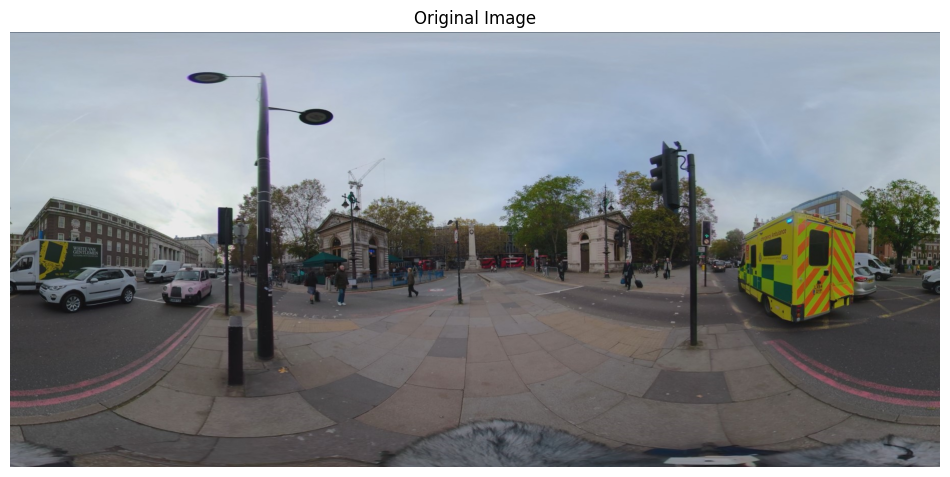

In [12]:
img_ds.seg.plot()

In [13]:
model, processor = cityseg.load_segmentation_model()

2025-06-11 13:10:52.470 | INFO     | cityseg.segmentation:load_segmentation_model:45 - Loading model nvidia/segformer-b0-finetuned-ade-512-512 on device mps
2025-06-11 13:10:52.810 | INFO     | cityseg.segmentation:load_segmentation_model:55 - Model loaded successfully


In [14]:
img_ds.image.data

array([[[ 70,  82,  96],
        [ 70,  82,  96],
        [ 70,  82,  96],
        ...,
        [ 70,  82,  96],
        [ 70,  82,  96],
        [ 70,  82,  96]],

       [[167, 179, 193],
        [167, 179, 193],
        [167, 179, 193],
        ...,
        [167, 179, 193],
        [167, 179, 193],
        [167, 179, 193]],

       [[169, 181, 195],
        [169, 181, 195],
        [169, 181, 195],
        ...,
        [169, 181, 195],
        [169, 181, 195],
        [168, 180, 194]],

       ...,

       [[ 87,  87,  95],
        [ 87,  87,  95],
        [ 87,  87,  95],
        ...,
        [ 93,  94,  99],
        [ 90,  91,  96],
        [ 87,  88,  93]],

       [[ 96,  96, 104],
        [ 97,  97, 105],
        [ 96,  96, 104],
        ...,
        [106, 107, 112],
        [104, 105, 110],
        [102, 103, 108]],

       [[121, 121, 129],
        [120, 120, 128],
        [120, 120, 128],
        ...,
        [115, 116, 121],
        [117, 118, 123],
        [118, 119, 124]]

In [6]:
processor(img_ds.image.data)

{'pixel_values': [array([[[-0.19993155, -0.19993155, -0.19993155, ..., -0.19993155,
         -0.19993155, -0.19993155],
        [ 0.7590547 ,  0.7590547 ,  0.7590547 , ...,  0.7761795 ,
          0.7590547 ,  0.7590547 ],
        [ 0.74193   ,  0.74193   ,  0.7590547 , ...,  0.74193   ,
          0.74193   ,  0.74193   ],
        ...,
        [-0.5424266 , -0.38830382, -0.19993155, ..., -0.2170563 ,
         -0.33692956, -0.43967807],
        [-0.59380084, -0.57667613, -0.45680285, ..., -0.25130582,
         -0.35405433, -0.5081771 ],
        [-0.23418105, -0.35405433, -0.5081771 , ..., -0.18280679,
         -0.19993155, -0.2170563 ]],

       [[ 0.13515405,  0.13515405,  0.13515405, ...,  0.13515405,
          0.13515405,  0.13515405],
        [ 1.1155462 ,  1.1155462 ,  1.1155462 , ...,  1.1330533 ,
          1.1155462 ,  1.1155462 ],
        [ 1.0980393 ,  1.0980393 ,  1.1155462 , ...,  1.0980393 ,
          1.0980393 ,  1.0980393 ],
        ...,
        [-0.42507   , -0.26750696, -

In [7]:
# Perform segmentation on the image dataset
img_ds = img_ds.seg.apply_segmentation(model, processor)
img_ds

2025-06-11 13:10:55.734 | INFO     | cityseg.components.media:validate_dataset:130 - MediaDataset validation passed
2025-06-11 13:10:55.975 | INFO     | cityseg.segmentation:apply_segmentation:536 - Applied segmentation to image


<xarray.Dataset> Size: 11MB
Dimensions:      (y: 857, x: 1833, rgb: 3, class_id: 150)
Coordinates:
  * y            (y) int64 7kB 0 1 2 3 4 5 6 7 ... 850 851 852 853 854 855 856
  * x            (x) int64 15kB 0 1 2 3 4 5 6 ... 1827 1828 1829 1830 1831 1832
  * rgb          (rgb) <U1 12B 'r' 'g' 'b'
  * class_id     (class_id) int64 1kB 0 1 2 3 4 5 6 ... 144 145 146 147 148 149
Data variables:
    image        (y, x, rgb) uint8 5MB 70 82 96 70 82 96 ... 118 123 118 119 124
    seg_map      (y, x) int32 6MB 2 2 2 2 2 2 2 2 2 ... 11 11 11 11 11 11 11 11
    class_label  (class_id) <U19 11kB 'wall' 'building' 'sky' ... 'clock' 'flag'
    palette      (class_id, rgb) uint8 450B 31 119 180 31 ... 229 158 218 229
Attributes:
    source_file:          /Users/mitch/Documents/GitHub/cityseg/example_input...
    media_type:           image
    width:                1833
    height:               857
    created_at:           2025-06-11T13:10:41.292536
    cityseg_version:      0.3.1rc0
    model_name:           nvidia/segformer-b0-finetuned-ade-512-512
    class_labels:         {0: 'wall', 1: 'building', 2: 'sky', 3: 'floor', 4:...
    model_version:        None
    has_segmentation:     True
    processing_metadata:  {'segmentation_applied_at': '2025-06-11T13:10:55.97...

2025-06-11 13:10:56.837 | INFO     | cityseg.components.media:validate_dataset:130 - MediaDataset validation passed


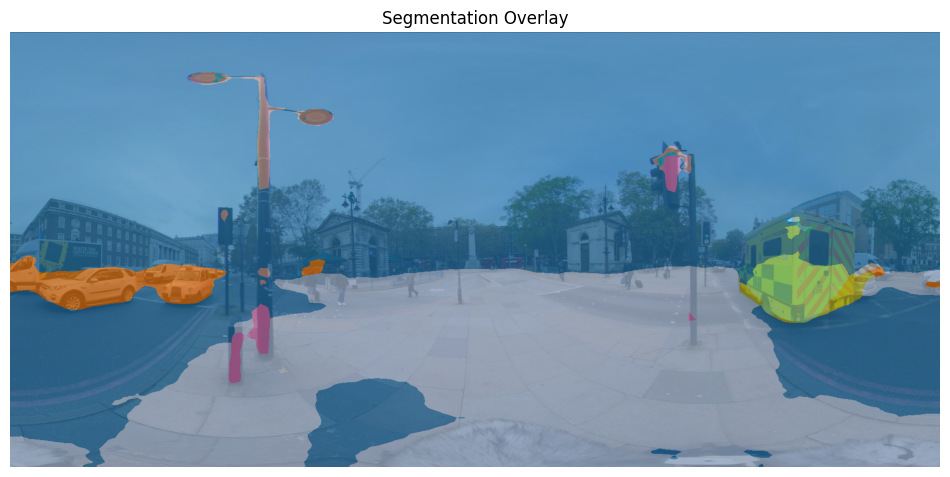

In [8]:
img_ds.seg.plot(kind="overlay")

In [9]:
test_vid = EXAMPLE_DIR / "Carlov2_15s_3840x2160.mov"
vid_ds = cityseg.load_video(test_vid)

2025-06-11 13:20:27.882 | INFO     | cityseg.components.media:validate_dataset:130 - MediaDataset validation passed
2025-06-11 13:20:27.884 | INFO     | cityseg.components.media:load_video:342 - Loaded video: example_inputs/Carlov2_15s_3840x2160.mov (450 frames, 3840x2160, 30.0 fps)


In [3]:
vid_seg = vid_ds.seg.apply_segmentation(model=model, processor=processor)

2025-06-04 13:34:37.480 | INFO     | cityseg.components.media:validate_dataset:124 - MediaDataset validation passed
2025-06-04 13:34:37.481 | INFO     | cityseg.segmentation:apply_segmentation:389 - Processing 450 video frames...
2025-06-04 13:34:48.526 | INFO     | cityseg.segmentation:apply_segmentation:430 - Processed 10/450 frames
2025-06-04 13:34:55.268 | INFO     | cityseg.segmentation:apply_segmentation:430 - Processed 20/450 frames
2025-06-04 13:35:02.028 | INFO     | cityseg.segmentation:apply_segmentation:430 - Processed 30/450 frames
2025-06-04 13:35:08.384 | INFO     | cityseg.segmentation:apply_segmentation:430 - Processed 40/450 frames
2025-06-04 13:35:14.633 | INFO     | cityseg.segmentation:apply_segmentation:430 - Processed 50/450 frames
2025-06-04 13:35:20.900 | INFO     | cityseg.segmentation:apply_segmentation:430 - Processed 60/450 frames
2025-06-04 13:35:27.145 | INFO     | cityseg.segmentation:apply_segmentation:430 - Processed 70/450 frames
2025-06-04 13:35:33.4

In [4]:
vid_seg

<xarray.Dataset> Size: 26GB
Dimensions:      (time: 450, y: 2160, x: 3840, rgb: 3, class_id: 150)
Coordinates:
  * time         (time) int64 4kB 0 1 2 3 4 5 6 ... 443 444 445 446 447 448 449
  * y            (y) int64 17kB 0 1 2 3 4 5 6 ... 2154 2155 2156 2157 2158 2159
  * x            (x) int64 31kB 0 1 2 3 4 5 6 ... 3834 3835 3836 3837 3838 3839
  * rgb          (rgb) <U1 12B 'r' 'g' 'b'
  * class_id     (class_id) int64 1kB 0 1 2 3 4 5 6 ... 144 145 146 147 148 149
Data variables:
    image        (time, y, x, rgb) uint8 11GB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    seg_map      (time, y, x) int32 15GB 2 2 2 2 2 2 2 2 2 ... 6 6 6 6 6 6 6 6 6
    class_label  (class_id) <U19 11kB 'wall' 'building' 'sky' ... 'clock' 'flag'
    palette      (class_id, rgb) uint8 450B 31 119 180 31 ... 229 158 218 229
Attributes: (12/13)
    source_file:          /Users/mitch/Documents/GitHub/cityseg/example_input...
    media_type:           video
    width:                3840
    height:               2160
    fps:                  29.97002997002997
    duration:             15.015
    ...                   ...
    cityseg_version:      0.3.1rc0
    model_name:           nvidia/segformer-b0-finetuned-ade-512-512
    class_labels:         {0: 'wall', 1: 'building', 2: 'sky', 3: 'floor', 4:...
    model_version:        None
    has_segmentation:     True
    processing_metadata:  {'segmentation_applied_at': '2025-06-04T13:40:13.15...

In [ ]:
set()
set(vid_seg.sizes.keys())

{'class_id', 'rgb', 'time', 'x', 'y'}

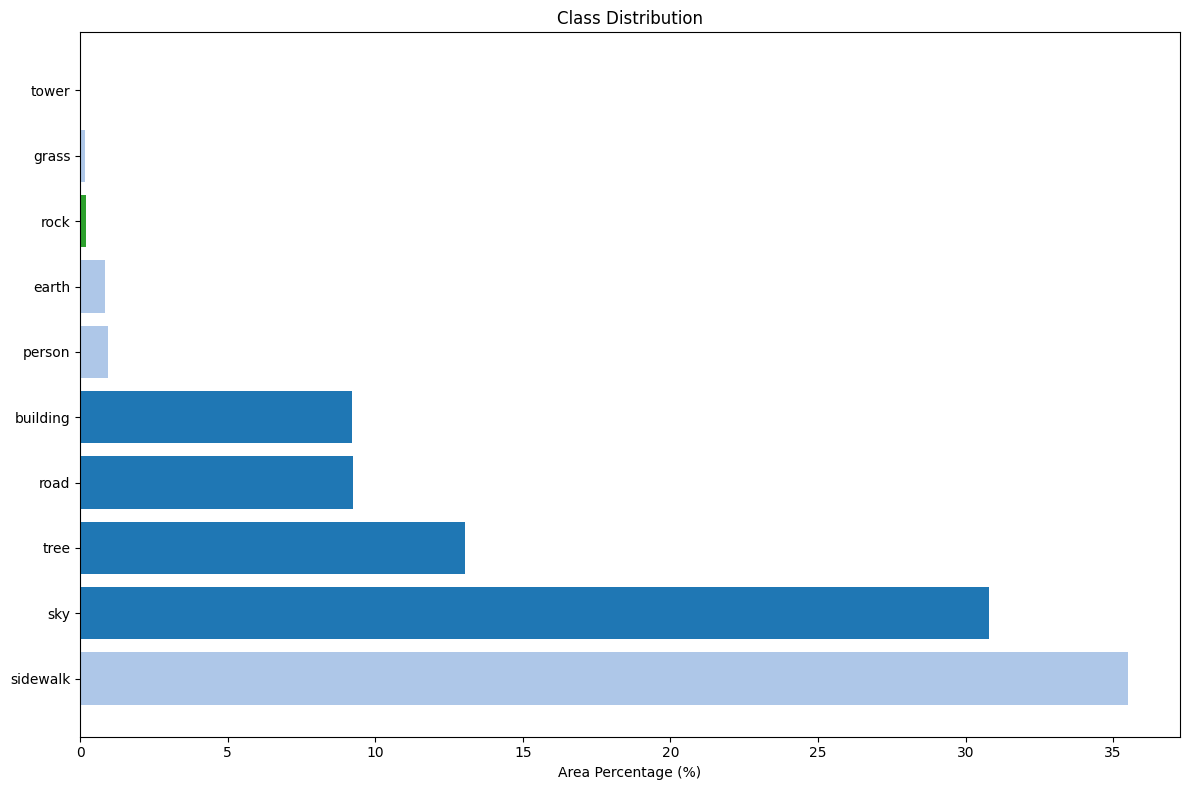

In [6]:
vid_seg.seg.plot(kind="stats")

In [ ]:
id2label = model.config.id2label
label_df = pd.DataFrame.from_dict(id2label, orient="index", columns=["class_label"])
label_df.index.name = "class_id"
# Add a new row for 'void' class
label_df.loc[len(label_df)] = ["void"]

data = xr.Dataset(
    data_vars=dict(
        image=(["y", "x", "rgb"], np.array(img)),
        seg_map=(["y", "x"], np.array(result["seg_map"])),
        palette=(["class_id", "rgb"], np.array(palette)),
        class_label=(["class_id"], label_df["class_label"].values),
    ),
    coords=dict(
        y=np.arange(result["seg_map"].shape[0]),
        x=np.arange(result["seg_map"].shape[1]),
        class_id=pd.Categorical(label_df.index, categories=label_df.index),
    ),
    attrs=dict(
        description="Segmentation map with class labels and palette",
        timestamp=datetime.now().isoformat(),
        **config.to_dict(),
    ),
)

data


NameError: name 'resized_image' is not defined